# Numerical Differentiation and Integration

Three groups of problems: finite-difference derivatives of increasing order checked against a
high-accuracy reference, definite integrals compared across rectangles/trapezoids/Simpson's 1/3
at several resolutions, and first- and second-order ODEs solved with Euler, midpoint, and Heun's
method.

## I. Finite-difference derivatives

For each function below, compute the first- and third-order finite-difference derivative
approximation with the same step h=0.01, and compare both against a high-accuracy reference
derivative (`scipy.optimize.approx_fprime`).

**1.** $y = \dfrac{\ln(x+2)}{\sin(x)} - (x+1)^4 e^{-2x}$, at $x=2$ and $x=4$

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

dx = 0.01  # step
x1 = 2     # points where the derivative is evaluated
x2 = 4


def f(x):
    return (np.log(x+2))/(np.sin(x)) - np.exp(-2*x)*(x+1)**4

# Redefine f as a vector function for approx_fprime
def f_vec(x_vec):
    return np.array([f(x_vec[0])])

# Numerical derivatives of different orders
def order_zero(x): 
    return ( f(x + dx) - f(x) ) / dx

def order_one(x):
    return ( -3*f(x) + 4*f(x+dx) - f(x+2*dx) ) / (2*dx)

def order_two(x):
    return ( -11*f(x) + 18*f(x+dx) - 9*f(x+2*dx) + 2*f(x+3*dx) ) / (6*dx)

def order_three(x):
    return ( -25*f(x) + 48*f(x+dx) - 36*f(x+2*dx) + 16*f(x+3*dx) - 3*f(x+4*dx) ) / (12*dx)

# Reference derivative using approx_fprime
epsilon = 1e-8
true_value1 = approx_fprime(np.array([x1]), f_vec, epsilon)[0]
true_value2 = approx_fprime(np.array([x2]), f_vec, epsilon)[0]

# Results
print(f"Reference derivative at x = {x1}, x = {x2} (via approx_fprime): x_1 = {true_value1:.6f}, x_2 =  {true_value2:.6f}\n")
 # order 1 for x1
print("Order one for x_1 = 2")
print(order_one(x1))
print(f"Absolute error: {np.abs(order_one(x1)-true_value1)}")
print(f"Relative error: {np.abs((order_one(x1)-true_value1)/true_value1)}\n")


# order 3 for x1
print("Order three for x_1 = 2")
print(order_three(x1))
print(f"Absolute error: {np.abs(order_three(x1)-true_value1)}")
print(f"Relative error: {np.abs((order_three(x1)-true_value1)/true_value1)}\n")

# order 1 for x2
print("Order one for x_2 = 4")
print(order_one(x2))
print(f"Absolute error: {np.abs(order_one(x2)-true_value2)}")
print(f"Relative error: {np.abs((order_one(x2)-true_value2)/true_value2)}\n")


# order 3 for x2
print("Order three for x_2 = 4")
print(order_three(x2))
print(f"Absolute error: {np.abs(order_three(x2)-true_value2)}")
print(f"Relative error: {np.abs((order_three(x2)-true_value2)/true_value2)}")


Reference derivative at x = 2, x = 4 (via approx_fprime): x_1 = 1.961716, x_2 =  2.076195

Order one for x_1 = 2
1.9615720187903585
Absolute error: 0.00014442687235094454
Relative error: 7.362270560063235e-05

Order three for x_1 = 2
1.961716244717778
Absolute error: 2.0094493136113556e-07
Relative error: 1.02433219543741e-07

Order one for x_2 = 4
2.075620448220006
Absolute error: 0.0005742472409315802
Relative error: 0.00027658641175946707

Order three for x_2 = 4
2.0761938592697446
Absolute error: 8.361911927323717e-07
Relative error: 4.0275182022210513e-07


**2.** $y = x\cos(x)\cos(3x)\cos(5x) - e^{-x^3}\sin(2x)\sin(4x)\sin(6x)$, at $x=1.5$

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

dx = 0.01  # step
x1 = 1.5     # point where the derivative is evaluated

def f(x):
    return x*np.cos(x)*np.cos(3*x)*np.cos(5*x)-np.exp(-x**3)*np.sin(2*x)*np.sin(4*x)*np.sin(6*x)

# Redefine f as a vector function for approx_fprime
def f_vec(x_vec):
    return np.array([f(x_vec[0])])

# Numerical derivatives of different orders
def order_zero(x): 
    return ( f(x + dx) - f(x) ) / dx

def order_one(x):
    return ( -3*f(x) + 4*f(x+dx) - f(x+2*dx) ) / (2*dx)

def order_two(x):
    return ( -11*f(x) + 18*f(x+dx) - 9*f(x+2*dx) + 2*f(x+3*dx) ) / (6*dx)

def order_three(x):
    return ( -25*f(x) + 48*f(x+dx) - 36*f(x+2*dx) + 16*f(x+3*dx) - 3*f(x+4*dx) ) / (12*dx)

# Reference derivative using approx_fprime
epsilon = 1e-8
true_value = approx_fprime(np.array([x1]), f_vec, epsilon)[0]

# Results
print(f"Reference derivative at x = {x1} (via approx_fprime): {true_value:.6f}\n")

print("Order one")
print(order_one(x1))
print(f"Absolute error: {np.abs(order_one(x1)-true_value)}")
print(f"Relative error: {np.abs((order_one(x1)-true_value)/true_value)}\n")

print("Order three")
print(order_three(x1))
print(f"Absolute error: {np.abs(order_three(x1)-true_value)}")
print(f"Relative error: {np.abs((order_three(x1)-true_value)/true_value)}")


Reference derivative at x = 1.5 (via approx_fprime): 0.290347

Order one
0.2880006898802665
Absolute error: 0.0023458592966130176
Relative error: 0.00807951499083916

Order three
0.2903666968997934
Absolute error: 2.0147722913865795e-05
Relative error: 6.939198337636096e-05


**3.** $y = \ln\!\left(\dfrac{\sin(x)}{x^3-2}\right)$, at $x=1$

In [3]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.optimize import approx_fprime

dx = 0.01  # step
x1 = 1     # point where the derivative is evaluated

def f(x):
    a = (np.sin(x)/(x**3 - 2))
    return np.log(np.abs(a))

# Redefine f as a vector function for approx_fprime
def f_vec(x_vec):
    return np.array([f(x_vec[0])])

# Numerical derivatives of different orders
def order_zero(x): 
    return ( f(x + dx) - f(x) ) / dx

def order_one(x):
    return ( -3*f(x) + 4*f(x+dx) - f(x+2*dx) ) / (2*dx)

def order_two(x):
    return ( -11*f(x) + 18*f(x+dx) - 9*f(x+2*dx) + 2*f(x+3*dx) ) / (6*dx)

def order_three(x):
    return ( -25*f(x) + 48*f(x+dx) - 36*f(x+2*dx) + 16*f(x+3*dx) - 3*f(x+4*dx) ) / (12*dx)

# Reference derivative using approx_fprime
epsilon = 1e-8
true_value = approx_fprime(np.array([x1]), f_vec, epsilon)[0]

# Results
print(f"Reference derivative at x = {x1} (via approx_fprime): {true_value:.6f}\n")

print("Order one")
print(order_one(x1))
print(f"Absolute error: {np.abs(order_one(x1)-true_value)}")
print(f"Relative error: {np.abs((order_one(x1)-true_value)/true_value)}\n")

print("Order three")
print(order_three(x1))
print(f"Absolute error: {np.abs(order_three(x1)-true_value)}")
print(f"Relative error: {np.abs((order_three(x1)-true_value)/true_value)}")


Reference derivative at x = 1 (via approx_fprime): 3.642093

Order one
3.6378798700066883
Absolute error: 0.004212804595201014
Relative error: 0.001156698901315439

Order three
3.6420357527647904
Absolute error: 5.692183709893328e-05
Relative error: 1.5628882124795275e-05


## II. Numerical integration

For each curve below, compute the area under the curve using rectangles, trapezoids, and
Simpson's 1/3 rule (n = 2, 4, and 10), and compare against a high-accuracy reference
(`scipy.integrate.quad`).

**1.** $y = -\arctan(\ln(x))$, on $[1, 5]$

    n   Riemann  Trapezoids   Simpson  Abs error Riemann  \
0   2 -1.664706   -2.679543 -2.896166           1.304904   
1   4 -2.384351   -2.891770 -2.962512           0.585258   
2  10 -2.754055   -2.957022 -2.969535           0.215555   

   Abs error Trapezoids  Abs error Simpson  Rel error Riemann  \
0              0.290067           0.073444           0.439419   
1              0.077840           0.007098           0.197083   
2              0.012588           0.000075           0.072587   

   Rel error Trapezoids  Rel error Simpson  
0              0.097678           0.024732  
1              0.026212           0.002390  
2              0.004239           0.000025  


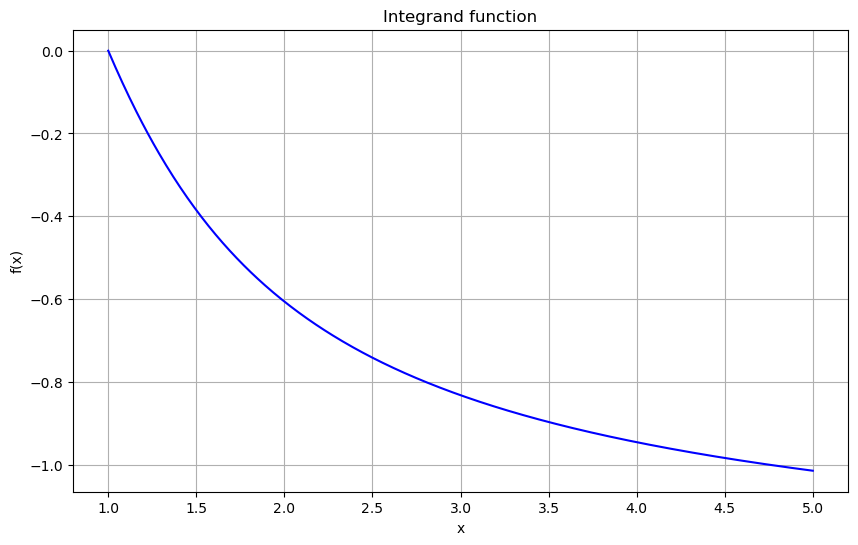

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

# Define the function
def f(x):
    return -np.arctan(np.log(x))

# Interval
a = 1
b = 5

# Reference value of the integral via scipy (very precise)
true_value, _ = quad(f, a, b)

# n values to test
n_vals = [2, 4, 10]

# Store results
results = []

for n in n_vals:
    dx = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)

    # Riemann (left)
    riemann_sum = 0
    for i in range(n):
        riemann_sum += f(a + i * dx)
    riemann_integral = dx * riemann_sum

    # Trapezoids
    trapezoid_sum = 0
    for i in range(1, n):
        trapezoid_sum += f(a + i * dx)
    trapezoid_integral = (dx / 2) * (f(a) + 2 * trapezoid_sum + f(b))

    # Simpson's 1/3 (n must be even)
    if n % 2 == 0:
        odd_sum = 0
        even_sum = 0
        for i in range(1, n):
            if i % 2 == 0:
                even_sum += f(a + i * dx)
            else:
                odd_sum += f(a + i * dx)
        simpson_integral = (dx / 3) * (f(a) + 4 * odd_sum + 2 * even_sum + f(b))
    else:
        simpson_integral = np.nan  # Simpson's rule requires even n

    results.append({
        "n": n,
        "Riemann": riemann_integral,
        "Trapezoids": trapezoid_integral,
        "Simpson": simpson_integral,
        "Abs error Riemann": abs(riemann_integral - true_value),
        "Abs error Trapezoids": abs(trapezoid_integral - true_value),
        "Abs error Simpson": abs(simpson_integral - true_value) if not np.isnan(simpson_integral) else np.nan,
        "Rel error Riemann": abs((riemann_integral - true_value) / true_value),
        "Rel error Trapezoids": abs((trapezoid_integral - true_value) / true_value),
        "Rel error Simpson": abs((simpson_integral - true_value) / true_value) if not np.isnan(simpson_integral) else np.nan
    })

# Show results
df = pd.DataFrame(results)
print(df)

# Plot the function
x_plot = np.linspace(a, b, 500)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, color="blue")
plt.title("Integrand function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()


**2.** $y = \dfrac{1}{\sin^2(x) + 3\sin(x)\cos(x) - \cos^2(x)}$, on $[0.4, 1.8]$

    n   Riemann  Trapezoids   Simpson  Abs error Riemann  \
0   2  2.233991    2.813595  2.134810           0.853992   
1   4  1.625714    1.915516  1.616156           0.245714   
2  10  1.384950    1.500870  1.414392           0.004950   

   Abs error Trapezoids  Abs error Simpson  Rel error Riemann  \
0              1.433596           0.754811           0.618835   
1              0.535516           0.236156           0.178054   
2              0.120871           0.034393           0.003587   

   Rel error Trapezoids  Rel error Simpson  
0              1.038838           0.546964  
1              0.388055           0.171128  
2              0.087588           0.024922  


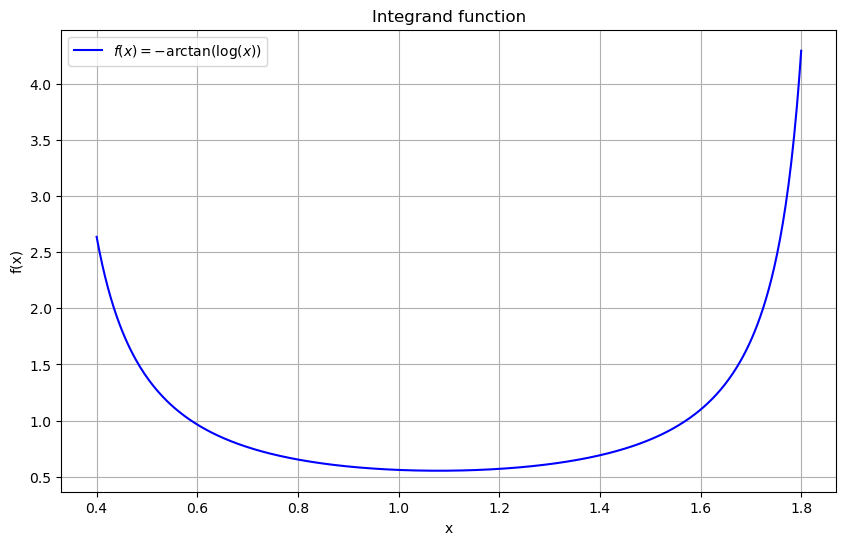

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

# Define the function
def f(x):
    return 1/(np.sin(x)**2+3*np.sin(x)*np.cos(x)-np.cos(x)**2)

# Interval
a = 0.4
b = 1.8

# Reference value of the integral via scipy (very precise)
true_value, _ = quad(f, a, b)

# n values to test
n_vals = [2, 4, 10]

# Store results
results = []

for n in n_vals:
    dx = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)

    # Riemann (left)
    riemann_sum = 0
    for i in range(n):
        riemann_sum += f(a + i * dx)
    riemann_integral = dx * riemann_sum

    # Trapezoids
    trapezoid_sum = 0
    for i in range(1, n):
        trapezoid_sum += f(a + i * dx)
    trapezoid_integral = (dx / 2) * (f(a) + 2 * trapezoid_sum + f(b))

    # Simpson's 1/3 (n must be even)
    if n % 2 == 0:
        odd_sum = 0
        even_sum = 0
        for i in range(1, n):
            if i % 2 == 0:
                even_sum += f(a + i * dx)
            else:
                odd_sum += f(a + i * dx)
        simpson_integral = (dx / 3) * (f(a) + 4 * odd_sum + 2 * even_sum + f(b))
    else:
        simpson_integral = np.nan  # Simpson's rule requires even n

    results.append({
        "n": n,
        "Riemann": riemann_integral,
        "Trapezoids": trapezoid_integral,
        "Simpson": simpson_integral,
        "Abs error Riemann": abs(riemann_integral - true_value),
        "Abs error Trapezoids": abs(trapezoid_integral - true_value),
        "Abs error Simpson": abs(simpson_integral - true_value) if not np.isnan(simpson_integral) else np.nan,
        "Rel error Riemann": abs((riemann_integral - true_value) / true_value),
        "Rel error Trapezoids": abs((trapezoid_integral - true_value) / true_value),
        "Rel error Simpson": abs((simpson_integral - true_value) / true_value) if not np.isnan(simpson_integral) else np.nan
    })

# Show results
df = pd.DataFrame(results)
print(df)

# Plot the function
x_plot = np.linspace(a, b, 500)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, label=r"$f(x) = -\arctan(\log(x))$", color="blue")
plt.title("Integrand function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.legend()
plt.show()


**3.** $y = e^x \sin(x)\sin(3x)$, on $[0, \pi/3]$

    n   Riemann  Trapezoids   Simpson  Abs error Riemann  \
0   2  0.441941    0.441941  0.589255           0.170807   
1   4  0.570322    0.570322  0.613115           0.042427   
2  10  0.605979    0.605979  0.612763           0.006770   

   Abs error Trapezoids  Abs error Simpson  Rel error Riemann  \
0              0.170807           0.023493           0.278755   
1              0.042427           0.000367           0.069240   
2              0.006770           0.000015           0.011048   

   Rel error Trapezoids  Rel error Simpson  
0              0.278755           0.038340  
1              0.069240           0.000599  
2              0.011048           0.000024  


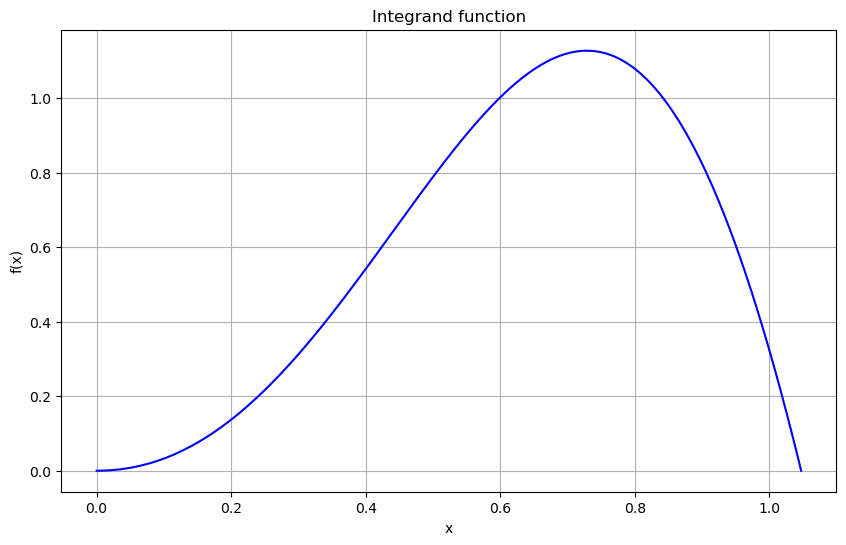

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import quad

# Define the function
def f(x):
    return np.exp(x)*np.sin(x)*np.sin(3*x)

# Interval
a = 0
b = np.pi/3

# Reference value of the integral via scipy (very precise)
true_value, _ = quad(f, a, b)

# n values to test
n_vals = [2, 4, 10]

# Store results
results = []

for n in n_vals:
    dx = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = f(x)

    # Riemann (left)
    riemann_sum = 0
    for i in range(n):
        riemann_sum += f(a + i * dx)
    riemann_integral = dx * riemann_sum

    # Trapezoids
    trapezoid_sum = 0
    for i in range(1, n):
        trapezoid_sum += f(a + i * dx)
    trapezoid_integral = (dx / 2) * (f(a) + 2 * trapezoid_sum + f(b))

    # Simpson's 1/3 (n must be even)
    if n % 2 == 0:
        odd_sum = 0
        even_sum = 0
        for i in range(1, n):
            if i % 2 == 0:
                even_sum += f(a + i * dx)
            else:
                odd_sum += f(a + i * dx)
        simpson_integral = (dx / 3) * (f(a) + 4 * odd_sum + 2 * even_sum + f(b))
    else:
        simpson_integral = np.nan  # Simpson's rule requires even n

    results.append({
        "n": n,
        "Riemann": riemann_integral,
        "Trapezoids": trapezoid_integral,
        "Simpson": simpson_integral,
        "Abs error Riemann": abs(riemann_integral - true_value),
        "Abs error Trapezoids": abs(trapezoid_integral - true_value),
        "Abs error Simpson": abs(simpson_integral - true_value) if not np.isnan(simpson_integral) else np.nan,
        "Rel error Riemann": abs((riemann_integral - true_value) / true_value),
        "Rel error Trapezoids": abs((trapezoid_integral - true_value) / true_value),
        "Rel error Simpson": abs((simpson_integral - true_value) / true_value) if not np.isnan(simpson_integral) else np.nan
    })

# Show results
df = pd.DataFrame(results)
print(df)

# Plot the function
x_plot = np.linspace(a, b, 500)
y_plot = f(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_plot, color="blue")
plt.title("Integrand function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()


## III. ODEs via Euler, midpoint, and Heun's method

Solve the ODEs below with all three methods over `0 <= t <= 3`, step `dt = 0.1`, and compare the
three approximations graphically.

**a)** $\dfrac{dx}{dt} = -x\sin^2(t)$, where $x(0)=1$

  t    Euler     Heun  Midpoint
0.0 1.000000 1.000000  1.000000
0.1 1.000000 0.999502  0.999750
0.2 0.999003 0.997033  0.997519
0.3 0.995060 0.990729  0.991425
0.4 0.986370 0.978956  0.979819
0.5 0.971412 0.960454  0.961422
0.6 0.949084 0.934457  0.935457
0.7 0.918826 0.900788  0.901742
0.8 0.880693 0.859881  0.860714
0.9 0.835372 0.812732  0.813383
1.0 0.784114 0.760790  0.761217
1.1 0.728593 0.705781  0.705969
1.2 0.670724 0.649532  0.649488
1.3 0.612459 0.593787  0.593538
1.4 0.555595 0.540067  0.539654
1.5 0.501641 0.489585  0.489054
1.6 0.451728 0.443203  0.442602
1.7 0.406594 0.401447  0.400816
1.8 0.366609 0.364544  0.363916
1.9 0.331841 0.332483  0.331883
2.0 0.302125 0.305082  0.304525
2.1 0.277145 0.282043  0.281538
2.2 0.256494 0.263004  0.262554
2.3 0.239728 0.247574  0.247178
2.4 0.226397 0.235356  0.235014
2.5 0.216067 0.225965  0.225673
2.6 0.208329 0.219023  0.218780
2.7 0.202792 0.214166  0.213970
2.8 0.199088 0.211030  0.210882
2.9 0.196854 0.209249  0.209149
3.0 0.19

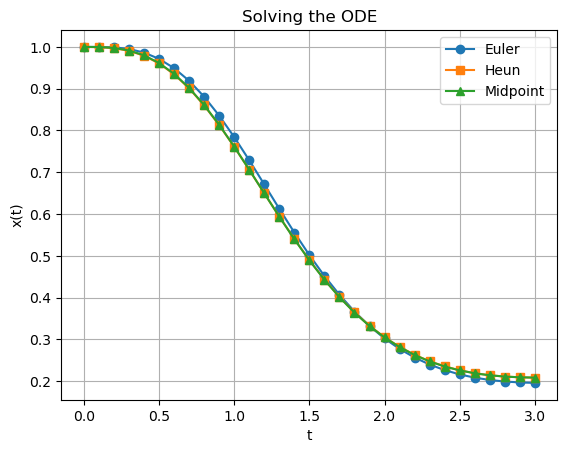

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Numerical methods
def euler_method(f, ti, xi, dt, final):
    x = [xi]
    t = [ti]
    n = int((final - ti) / dt)
    for j in range(n):
        t.append(t[j] + dt)
        x.append(x[j] + f(t[j], x[j]) * dt)
    return t, x

def heun_method(f, ti, xi, dt, final):
    x = [xi]
    t = [ti]
    n = int((final - ti) / dt)
    for j in range(n):
        t_pred = t[j] + dt
        x_pred = x[j] + f(t[j], x[j]) * dt
        k1 = f(t[j], x[j])
        k2 = f(t_pred, x_pred)
        t.append(t_pred)
        x.append(x[j] + (k1 + k2) * dt / 2)
    return t, x

def midpoint_method(f, ti, xi, dt, final):
    x = [xi]
    t = [ti]
    n = int((final - ti) / dt)
    for j in range(n):
        t_mid = t[j] + dt / 2
        x_mid = x[j] + f(t[j], x[j]) * dt / 2
        k = f(t_mid, x_mid)
        t.append(t[j] + dt)
        x.append(x[j] + k * dt)
    return t, x

# ODE: dx/dt = -x*sin(t)^2
def f(t, x):
    return -x * (np.sin(t))**2

# Initial conditions
t0 = 0
tf = 3
x0 = 1
dt = 0.1


# Solve with all three methods
te, xe = euler_method(f, t0, x0, dt, tf)
th, xh = heun_method(f, t0, x0, dt, tf)
tm, xm = midpoint_method(f, t0, x0, dt, tf)

# Show the results as a table
table = pd.DataFrame({
    't': te,  # times are the same for all methods
    'Euler': xe,
    'Heun': xh,
    'Midpoint': xm
})

# Show the table
print(table.to_string(index=False))

# Plot the results
plt.plot(te, xe, 'o-', label="Euler")
plt.plot(th, xh, 's-', label="Heun")
plt.plot(tm, xm, '^-', label="Midpoint")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Solving the ODE")
plt.grid(True)
plt.legend()
plt.show()


**b)** $\dfrac{d^2y}{dt^2} - t + y = 0$, where $y(0)=2$, $y'(0)=1$

  t    Euler     Heun  Midpoint
0.0 2.000000 2.000000  2.000000
0.1 2.100000 2.090000  2.090000
0.2 2.180000 2.160050  2.160050
0.3 2.240000 2.210450  2.210450
0.4 2.280200 2.241696  2.241696
0.5 2.301000 2.254478  2.254478
0.6 2.302998 2.249668  2.249668
0.7 2.286986 2.228318  2.228318
0.8 2.253944 2.191644  2.191644
0.9 2.205032 2.141015  2.141015
1.0 2.141581 2.077941  2.077941
1.1 2.065079 2.004057  2.004057
1.2 1.977162 1.921105  1.921105
1.3 1.879594 1.830920  1.830920
1.4 1.774254 1.735407  1.735407
1.5 1.663118 1.636527  1.636527
1.6 1.548240 1.536273  1.536273
1.7 1.431730 1.436654  1.436654
1.8 1.315738 1.339669  1.339669
1.9 1.202429 1.247294  1.247294
2.0 1.093963 1.161458  1.161458
2.1 0.992472 1.084023  1.084023
2.2 0.900041 1.016769  1.016769
2.3 0.818686 0.961373  0.961373
2.4 0.750331 0.919393  0.919393
2.5 0.696788 0.892252  0.892252
2.6 0.659742 0.881226  0.881226
2.7 0.640729 0.887427  0.887427
2.8 0.641118 0.911798  0.911798
2.9 0.662099 0.955096  0.955096
3.0 0.70

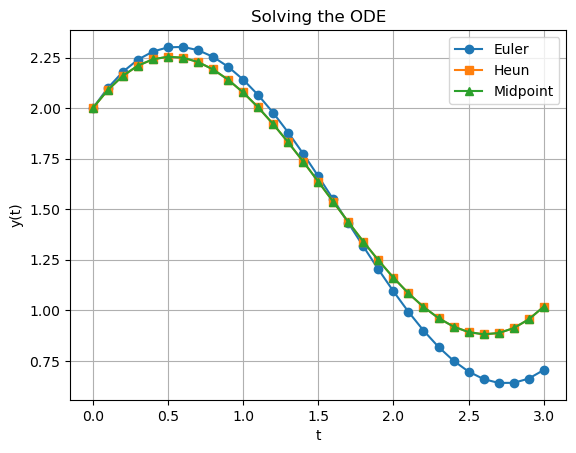

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Numerical methods for a 2-variable system
def euler_method(f1, f2, ti, y0, y1, dt, tf):
    t = [ti]
    y = [y0]
    yp = [y1]
    n = int((tf - ti) / dt)
    for j in range(n):
        t.append(t[j] + dt)
        yp.append(yp[j] + f2(t[j], y[j], yp[j]) * dt)
        y.append(y[j] + f1(t[j], y[j], yp[j]) * dt)
    return t, y, yp

def heun_method(f1, f2, ti, y0, y1, dt, tf):
    t = [ti]
    y = [y0]
    yp = [y1]
    n = int((tf - ti) / dt)
    for j in range(n):
        t_pred = t[j] + dt
        y_pred = y[j] + f1(t[j], y[j], yp[j]) * dt
        yp_pred = yp[j] + f2(t[j], y[j], yp[j]) * dt
        k1_y = f1(t[j], y[j], yp[j])
        k2_y = f1(t_pred, y_pred, yp_pred)
        k1_yp = f2(t[j], y[j], yp[j])
        k2_yp = f2(t_pred, y_pred, yp_pred)
        t.append(t_pred)
        y.append(y[j] + (k1_y + k2_y) * dt / 2)
        yp.append(yp[j] + (k1_yp + k2_yp) * dt / 2)
    return t, y, yp

def midpoint_method(f1, f2, ti, y0, y1, dt, tf):
    t = [ti]
    y = [y0]
    yp = [y1]
    n = int((tf - ti) / dt)
    for j in range(n):
        t_mid = t[j] + dt / 2
        y_mid = y[j] + f1(t[j], y[j], yp[j]) * dt / 2
        yp_mid = yp[j] + f2(t[j], y[j], yp[j]) * dt / 2
        k_y = f1(t_mid, y_mid, yp_mid)
        k_yp = f2(t_mid, y_mid, yp_mid)
        t.append(t[j] + dt)
        y.append(y[j] + k_y * dt)
        yp.append(yp[j] + k_yp * dt)
    return t, y, yp

# System equations
def f1(t, y, yp):
    return yp

def f2(t, y, yp):
    return t - y  # since the equation is y'' = t - y

# Initial conditions
t0 = 0
tf = 3
y0 = 2      # y(0)
yp0 = 1     # y'(0)
dt = 0.1

# Solve with all three methods
te, ye, ype = euler_method(f1, f2, t0, y0, yp0, dt, tf)
th, yh, yph = heun_method(f1, f2, t0, y0, yp0, dt, tf)
tm, ym, ypm = midpoint_method(f1, f2, t0, y0, yp0, dt, tf)

# Build a results table
table = pd.DataFrame({
    't': te,
    'Euler': ye,
    'Heun': yh,
    'Midpoint': ym
})
print(table.to_string(index=False))

# Plot the results
plt.plot(te, ye, 'o-', label="Euler")
plt.plot(th, yh, 's-', label="Heun")
plt.plot(tm, ym, '^-', label="Midpoint")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Solving the ODE")
plt.grid(True)
plt.legend()
plt.savefig("ode_euler_heun_midpoint_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

    